# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Afia Nyarkoa Otieku-Boadu
**Student ID:** 55002028

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [18]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

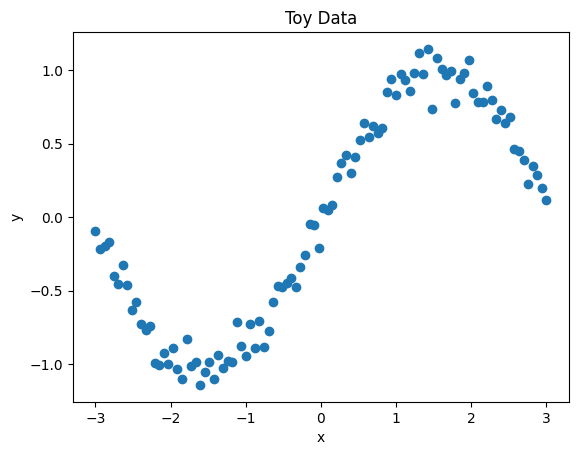

[np.float64(0.5319618242000635), np.float64(0.4920286153564831), np.float64(0.45683445786818355), np.float64(0.4258169383733008), np.float64(0.3984803890397071), np.float64(0.3743879663916405), np.float64(0.3531546701996664), np.float64(0.3344411908697882), np.float64(0.3179484870076631), np.float64(0.30341300650270436), np.float64(0.29060247476086953), np.float64(0.27931218277845704), np.float64(0.2693617157371307), np.float64(0.26059206984030125), np.float64(0.2528631113154318), np.float64(0.24605133697493933), np.float64(0.24004790054753616), np.float64(0.23475687323909378), np.float64(0.230093710725306), np.float64(0.2259839020773851), np.float64(0.2223617790294738), np.float64(0.21916946655885292), np.float64(0.21635595800832952), np.float64(0.21387629997047736), np.float64(0.21169087390749358), np.float64(0.2097647630263538), np.float64(0.2080671942914006), np.float64(0.20657104665726034), np.float64(0.20525241766324331), np.float64(0.20409024146304655), np.float64(0.203065952185

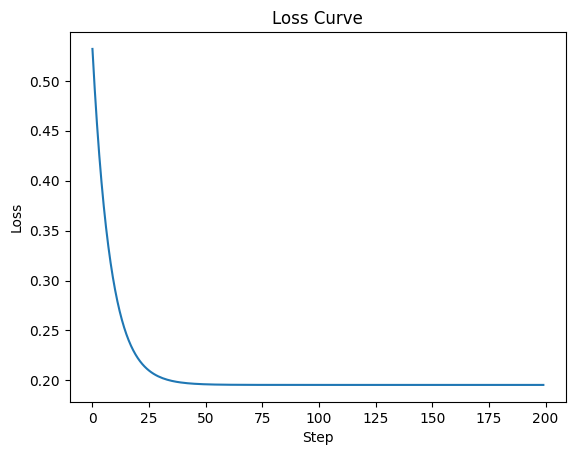

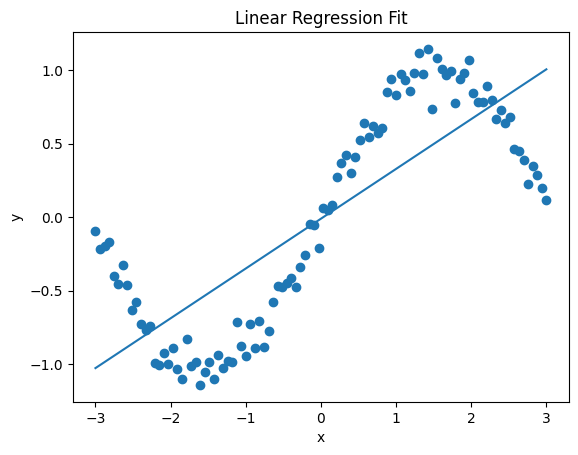

In [19]:
# TODO: Generate the toy data
x = np.linspace(-3, 3, 100); y = np.sin(x) + np.random.normal(0, 0.1, 100)
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

#   Plot it.

plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Toy Data")

plt.show()


# TODO: Initialise w and b to small random values.

w = np.random.randn() * 0.01
b = np.random.randn() * 0.01
lr = 0.01

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
y_hat = w * x + b
loss  = np.mean((y_hat - y) ** 2)               # MSE
dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
db    = np.mean(2 * (y_hat - y))                # dLoss/db
w    -= lr * dw
b    -= lr * db

losses = []

for i in range(200):
  y_hat = w * x + b
  loss  = np.mean((y_hat - y) ** 2)               # MSE
  dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
  db    = np.mean(2 * (y_hat - y))                # dLoss/db
  w    -= lr * dw
  b    -= lr * db

  #   Record the loss at every step.

  losses.append(loss)

print(losses)

# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.

plt.plot(losses)

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss Curve")

plt.show()

plt.scatter(x, y)
plt.plot(x, y_hat)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression Fit")

plt.show()

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:** 1.
2. Underfitting because the model is too simple to learn the true relationship of the data. A single neuron can only compute a linear function and since a sine wave is non-linear, no matter how long it is trained it can never fit the wave without an activation function.

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

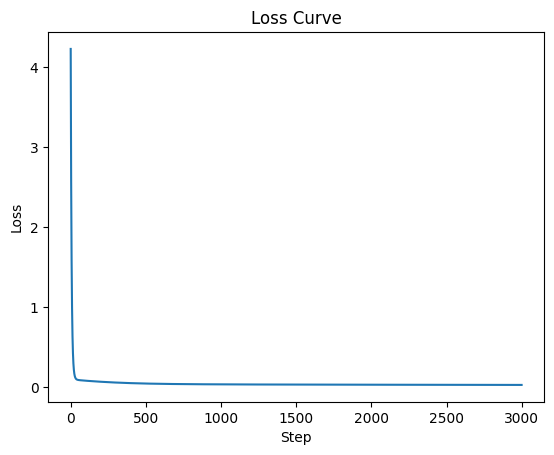

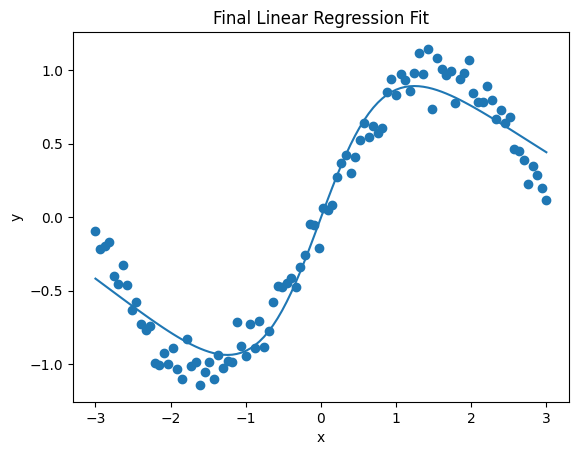

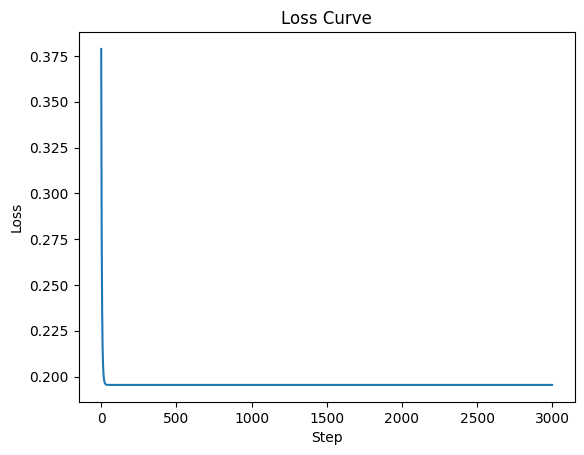

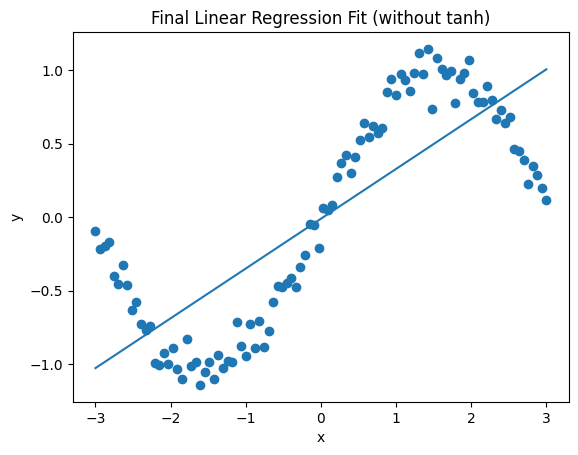

In [20]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)
W1 = np.random.randn(1,8) * 0.5
b1 = np.random.randn(8) * 0.5

W2 = np.random.randn(8,1) * 0.5
b2 = np.random.randn(1) * 0.5

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
h  = np.tanh(z1)        # activation
y_hat = h @ W2 + b2     # output, shape (100, 1)
loss  = np.mean((y_hat - y) ** 2)

# TODO: Backward pass (the chain rule, layer by layer):
d_yhat = 2 * (y_hat - y) / len(y)
dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
dh  = d_yhat @ W2.T
dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.

losses2 = []

for i in range(3000):
  z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
  h  = np.tanh(z1)        # activation
  y_hat = h @ W2 + b2     # output, shape (100, 1)
  loss  = np.mean((y_hat - y) ** 2)

  # TODO: Backward pass (the chain rule, layer by layer):
  d_yhat = 2 * (y_hat - y) / len(y)
  dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
  dh  = d_yhat @ W2.T
  dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
  dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

  W1 -= lr*dW1
  b1 -= lr*db1
  W2 -= lr*dW2
  b2 -= lr*db2

  losses2.append(loss)


# TODO: Plot the loss curve AND the final fit over the data.

plt.plot(losses2)

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss Curve")

plt.show()

plt.scatter(x, y)
plt.plot(x, y_hat)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Final Linear Regression Fit")

plt.show()
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?

W1 = np.random.randn(1,8) * 0.5
b1 = np.random.randn(8) * 0.5

W2 = np.random.randn(8,1) * 0.5
b2 = np.random.randn(1) * 0.5

# TODO: Forward pass
z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
h  = z1       # activation
y_hat = h @ W2 + b2     # output, shape (100, 1)
loss  = np.mean((y_hat - y) ** 2)

# TODO: Backward pass (the chain rule, layer by layer):
d_yhat = 2 * (y_hat - y) / len(y)
dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
dh  = d_yhat @ W2.T
dz1 = dh * (1 - z1 ** 2)     # derivative of tanh
dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.

losses3 = []

for i in range(3000):
  z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
  h  = z1        # activation
  y_hat = h @ W2 + b2     # output, shape (100, 1)
  loss  = np.mean((y_hat - y) ** 2)

  # TODO: Backward pass (the chain rule, layer by layer):
  d_yhat = 2 * (y_hat - y) / len(y)
  dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
  dh  = d_yhat @ W2.T
  dz1 = dh      # derivative of h
  dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

  W1 -= lr*dW1
  b1 -= lr*db1
  W2 -= lr*dW2
  b2 -= lr*db2

  losses3.append(loss)


# TODO: Plot the loss curve AND the final fit over the data.

plt.plot(losses3)

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss Curve")

plt.show()

plt.scatter(x, y)
plt.plot(x, y_hat)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Final Linear Regression Fit (without tanh)")

plt.show()

**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:** 1. Linear layers can only perform linear computations. Multiple linear computations can always be represented as one linear computation and as such will always produce a linear output. This same reasoning explains why multiple linear layers collapse into one linear layer.
2.
3. Backpropagation refers to determining the amount each weight contributed to the final loss to readjust them to reduce the loss.

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

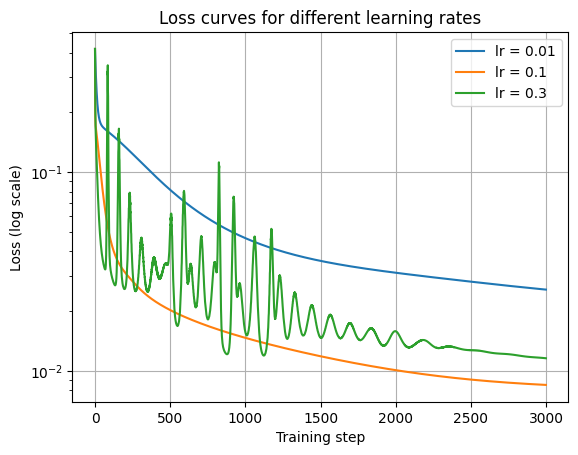

In [21]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.
def train_toy(lr, steps = 3000):
  W1 = W1_initial.copy()
  b1 = b1_initial.copy()
  W2 = W2_initial.copy()
  b2 = b2_initial.copy()

  losses = []

  for i in range(steps):
    # Forward pass
    z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
    h  = np.tanh(z1)        # activation
    y_hat = h @ W2 + b2     # output, shape (100, 1)
    loss  = np.mean((y_hat - y) ** 2)

    # Backward pass
    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
    dh  = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
    dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

    W1 -= lr*dW1
    b1 -= lr*db1
    W2 -= lr*dW2
    b2 -= lr*db2

    losses.append(loss)

  return losses

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).

W1_initial = np.random.randn(1,8) * 0.5
b1_initial = np.random.randn(8) * 0.5
W2_initial = np.random.randn(8,1) * 0.5
b2_initial = np.random.randn(1) * 0.5

losses_a = train_toy(0.01)
losses_b = train_toy(0.1)
losses_c = train_toy(0.3)

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.

plt.plot(losses_a, label="lr = 0.01")
plt.plot(losses_b, label="lr = 0.1")
plt.plot(losses_c, label="lr = 0.3")

plt.yscale("log")

plt.xlabel("Training step")
plt.ylabel("Loss (log scale)")
plt.title("Loss curves for different learning rates")

plt.legend()
plt.grid(True)

plt.show()

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:** The learning rate of 0.01 shows a gradual descen. This is also the same for the learning rate of 0.1 which just shows a slightly steeper initial descent but later continues to grow at a similar rate to that of 0.01. However, with the learning rate of 0.3, the line begins to oscillate. This is because a too-large learning rate results in the model taking large steps during gradient descent, meaning it may easily miss the optimal solution, resulting in the loss explode or oscillation.

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [22]:
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity = pd.read_csv(OBESITY_URL)

# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).

# Separating numeric and categorical columns
num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
cat_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']

#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in binary_cols:
    obesity[col] = obesity[col].map({
        "yes": 1,
        "no": 0
    })

#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS)
from sklearn.preprocessing import OrdinalEncoder
# Ordinal columns
ordinal_cols= ["CAEC", "CALC"]

encoder = OrdinalEncoder(
    categories=[
        ["no","Sometimes","Frequently","Always"],
        ["no","Sometimes","Frequently","Always"]
    ]
)

obesity[ordinal_cols] = encoder.fit_transform(
    obesity[ordinal_cols]
)

# Nominal columns
nominal_cols = ["Gender", "MTRANS"]

obesity = pd.get_dummies(
    obesity,
    columns=nominal_cols,
    drop_first=True
)

#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.
# Encoding the target `NObeyesdad` into integer class labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(obesity["NObeyesdad"])

# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
# Separating X (features) and y (encoded NObeyesdad).
X = obesity.drop(columns=["NObeyesdad"])
X = X.astype(np.float32)

# Splitting the dataset into train, validation and test (using stratify=y so every split has all 7 classes)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=RANDOM_STATE, stratify=y_temp
)

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)
# Fitting the scaler on the training set and transforming train, val and test.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
X_train = X_train.to_numpy()
X_val = X_val.to_numpy()
X_test = X_test.to_numpy()

import torch
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val   = torch.tensor(y_val, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

from torch.utils.data import TensorDataset

train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val, y_val)
test_dataset  = TensorDataset(X_test, y_test)

#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Train: (1350, 19)
Validation: (338, 19)
Test: (423, 19)


**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:** 1. CrossEntropyLoss uses integers to represent the different classes so that it can compare the model's output directly with the class index which is more efficient than using one-hot vectors.
2. Random forests focus more on features than on their values. Since neural networks use gradient decent to update their weights, the size of the gradient is affected by the size of the value. In order to prevent false weight updates, the features are scaled to similar sizes so that no one feature is given much priority over another.
3. It shuffles the order of the data, preventing the model from memorising patterns due to the order it is represented which may lead to overfitting.

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [23]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

class FeedForwardNet(nn.Module):
  def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
    super().__init__()
    self.relu = nn.ReLU() #activation function
    self.fc1 = nn.Linear(input_dim, hidden_sizes[0]) #linear layer 1
    self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
    self.classifier = nn.Linear(hidden_sizes[1], n_classes)

  def forward(self, x):
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    x = self.relu(x)
    out = self.classifier(x)
    return out

# TODO: Instantiate, move to DEVICE, print the model.

input_dim = X_train.shape[1]

model = FeedForwardNet(input_dim)
model = model.to(DEVICE)
print(model)

# TODO: Count trainable parameters:
sum_param = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(sum_param)

#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.
sum_layer1 = model.fc1.weight.numel() + model.fc1.bias.numel()
print(sum_layer1 == (input_dim*64 + 64))

FeedForwardNet(
  (relu): ReLU()
  (fc1): Linear(in_features=19, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (classifier): Linear(in_features=32, out_features=7, bias=True)
)
3591
True


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:** 1.
2. ReLU does not cause much change as it only discards negative values, leaving positive values unchanged, unlike tanh which has to handle the vanishing gradient problem for positive values.
3. If the ReLUs were removed, the model will be full of linear functions which can only learn linear relationships. This will mean that the model would compute only linear computations to produce a linear output.

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Epoch 1: Losses: 1.8082547686820807 (training), 1.803819710558111 (validation) 
 Accuracy: 0.17037037037037037 (training), 0.17751479289940827 (validation)
Epoch 2: Losses: 1.6942538050718086 (training), 1.6941310492428867 (validation) 
 Accuracy: 0.2348148148148148 (training), 0.257396449704142 (validation)
Epoch 3: Losses: 1.604554714158524 (training), 1.595718589696017 (validation) 
 Accuracy: 0.3207407407407407 (training), 0.3520710059171598 (validation)
Epoch 4: Losses: 1.5248210818268533 (training), 1.5057550343600186 (validation) 
 Accuracy: 0.31925925925925924 (training), 0.34023668639053256 (validation)
Epoch 5: Losses: 1.4299417595530666 (training), 1.3967781175266614 (validation) 
 Accuracy: 0.42148148148148146 (training), 0.4378698224852071 (validation)
Epoch 6: Losses: 1.3807145551193591 (training), 1.3584638833999634 (validation) 
 Accuracy: 0.46370370370370373 (training), 0.47041420118343197 (validation)
Epoch 7: Losses: 1.3219248389088831 (training), 1.2893854271281848 

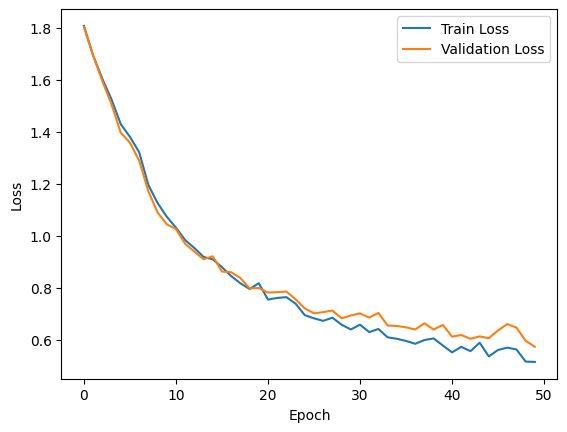

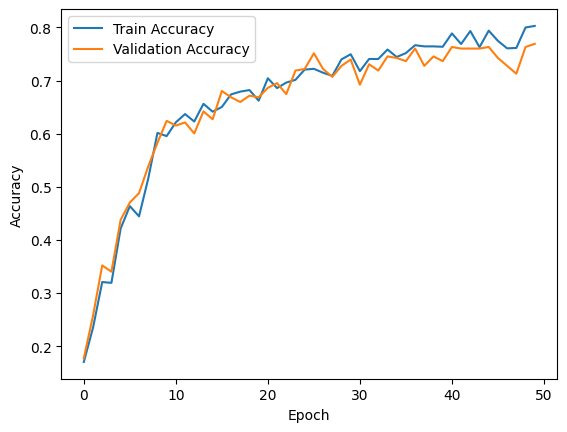

In [24]:
# TODO:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify

train_losses = []
val_losses = []
train_accuracy = []
val_accuracy = []

highest_val_accuracy = 0

# TODO: Train for at least 50 epochs. Each epoch:
for epoch in range(50):
  model.train()
  for xb, yb in train_loader:
    optimizer.zero_grad()
    logits = model(xb.to(DEVICE))
    loss = criterion(logits, yb.to(DEVICE))
    loss.backward()          # <- the backprop you wrote by hand in Part 1.2
    optimizer.step()         # <- the update rule you wrote in Part 1.1

#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
  model.eval()

  train_loss = 0
  correct = 0
  total = 0

  with torch.no_grad():
    for xb, yb in train_loader:
      xb = xb.to(DEVICE)
      yb = yb.to(DEVICE)
      logits = model(xb)
      loss = criterion(logits, yb)

      train_loss += loss.item()
      predictions = torch.argmax(logits, dim=1)
      correct += (predictions == yb).sum().item()
      total += yb.size(0)

  train_loss /= len(train_loader)
  train_acc = correct / total

  val_loss = 0
  correct = 0
  total = 0

  with torch.no_grad():
    for xb, yb in val_loader:
      xb = xb.to(DEVICE)
      yb = yb.to(DEVICE)
      logits = model(xb)
      loss = criterion(logits, yb)

      val_loss += loss.item()
      predictions = torch.argmax(logits, dim=1)
      correct += (predictions == yb).sum().item()
      total += yb.size(0)

  val_loss /= len(val_loader)
  val_acc = correct / total

#   3. Append everything to history lists; print a one-line summary per epoch.
  train_losses.append(train_loss)
  val_losses.append(val_loss)
  train_accuracy.append(train_acc)
  val_accuracy.append(val_acc)

  print(f"Epoch {epoch+1}: Losses: {train_loss} (training), {val_loss} (validation) \n Accuracy: {train_acc} (training), {val_acc} (validation)")

# TODO: Save the best model (highest validation accuracy):
  if val_acc > highest_val_accuracy:
    highest_val_accuracy = val_acc
    torch.save(model.state_dict(), "ffn_best.pt")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(train_accuracy, label="Train Accuracy")
plt.plot(val_accuracy, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:** [Double-click to edit]

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

In [25]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:** [Double-click to edit]

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

In [26]:
# TODO: Load your best configuration's weights; model.eval().

# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay

# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** [Double-click to edit]

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** [Double-click to edit]

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.